In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties, fontManager
from matplotlib.patches import Rectangle
from scipy.stats import gaussian_kde

font_path = "/usr/share/fonts/myFonts/arial.ttf"
ifont_path = "/usr/share/fonts/myFonts/ariali.ttf"

fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
font_name = font_prop.get_name()
fontManager.addfont(ifont_path)
ifont_prop = FontProperties(fname=ifont_path)
ifont_name = ifont_prop.get_name()

plt.rcParams["font.family"] = [font_name]
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
})

italic_font = FontProperties(fname=ifont_path)
normal_font = FontProperties(fname=font_path)
legend_font = FontProperties(fname=ifont_path, size=7)
title_font = FontProperties(fname=ifont_path, size=8)

In [2]:
import ast
import os
import pandas as pd
import textract

# chromid reference data

file_path = "/active-data/analysis_results/chr_pla/reference_data/PMID20080407/1-s2.0-S0966842X09002698-mmc1.doc"
content = textract.process(file_path, encoding="utf-8")
content = content.decode("utf-8")

ref1_list = []
for line in content.splitlines():
    if "Chromid" in line and '|' in line:
        parts = line.split("|")
        nc_code = parts[4].strip()
        ref1_list.append(nc_code.replace(' ', '_'))

file_path = "/active-data/analysis_results/chr_pla/reference_data/PMID40827884/msystems.00175-25-s0003.xlsx"

df = pd.read_excel(file_path, skiprows=1)
chromid_ref = df[df['GC_difference_%'] != 0]
ref2_list = chromid_ref['Replicon_Accession'].to_list()

# chromid-finder data

def extract_name(x):
    try:
        genus_dict = ast.literal_eval(x)
        return genus_dict.get('name', None)
    except:
        return None

os.chdir('/active-data/analysis_results/chr_pla')
all_data = pd.read_csv('genome_chr-pla_statistics.csv')
all_data['genus_clean'] = all_data['genus'].apply(extract_name)
counts = all_data['genus_clean'].value_counts()
keep_genus = counts[counts >= 400].index.to_list()
filted_data = all_data[all_data['genus_clean'].isin(keep_genus)]

found_chromids = []
chromid_dir = '/active-data/genomes/bacteria_complete_annotationRefSeq-20250807/chromid_results'
for acc_n in filted_data['accession']:
    file_path = f'{chromid_dir}/{acc_n}.txt'
    
    if os.path.getsize(file_path) == 0:
        continue
    
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        
        for i, line in enumerate(lines):
            if "Possible bacterial chromids:" in line:
                if i + 1 >= len(lines):
                    continue
                chromid_line = lines[i+1].strip()
                if not chromid_line or chromid_line == '------':
                    break
                
                chromid_list = [c.strip() for c in chromid_line.split(",") if c.strip()]
                for chromid in chromid_list:
                    found_chromids.append(chromid.split('.')[0])


def chromid_info_(contig_info, all_chromids=set(ref1_list + ref2_list + found_chromids)):
    contig_info = contig_info.copy()
    contig_info['contig'] = contig_info['accession'].apply(
        lambda x: x.split('-')[-1].split('.')[0]
    )
    chromid_result = contig_info[contig_info['contig'].isin(all_chromids)].copy()
    return chromid_result

def chromid_info_genus(genus_name, all_chromids=set(ref1_list + ref2_list + found_chromids)):
    work_dir = f'/active-data/analysis_results/chr_pla/genus/statistics_records/{genus_name}'
    os.chdir(work_dir)
    contig_info = pd.read_csv('replicon-plasmid_fraction-self_bitscore_statistics.csv')
    contig_info['contig'] = contig_info['accession'].apply(lambda x: x.split('-')[-1].split('.')[0])
    total_contig = len(contig_info)
    all_category_raw = contig_info['category-pident_90'].value_counts()
    chromid_result = contig_info[contig_info['contig'].isin(all_chromids)]
    chromid_raw = chromid_result['category-pident_90'].value_counts()
    chromid_pct = (chromid_raw / total_contig * 100).fillna(0)
    return chromid_raw, total_contig, chromid_pct

genus_result_dict = {}
all_categories = set()
for genus_name in keep_genus:
    raw_series, total_num, pct_series = chromid_info_genus(genus_name)
    genus_result_dict[genus_name] = {
        "raw_counts": raw_series,
        "total_replicon": total_num,
        "percent": pct_series
    }
    all_categories.update(raw_series.index.tolist())

all_categories = sorted(list(all_categories))

pct_df = pd.DataFrame(columns=keep_genus, index=all_categories, dtype=float)
raw_df = pd.DataFrame(columns=keep_genus, index=all_categories, dtype=int)
total_replicon_dict = {}

for genus in keep_genus:
    item = genus_result_dict[genus]
    total_replicon_dict[genus] = item["total_replicon"]
    for cat in all_categories:
        if cat in item["percent"].index:
            pct_df.loc[cat, genus] = item["percent"][cat]
        else:
            pct_df.loc[cat, genus] = 0
    for cat in all_categories:
        if cat in item["raw_counts"].index:
            raw_df.loc[cat, genus] = item["raw_counts"][cat]
        else:
            raw_df.loc[cat, genus] = 0

pct_plot_df = pct_df.T
raw_plot_df = raw_df.T

In [3]:
label = 'pident_90'

def scatter_figure(ax, df, genus_name):    
    def process_replicon_data(fraction_data):
        typ_chr = fraction_data[fraction_data[f'category-{label}'] == 'typical chromosome']
        min_size = min(typ_chr['size'])
        tra_rep = fraction_data[fraction_data[f'category-{label}'] == 'intermediate replicon']
        if tra_rep.empty:
            return min_size * 0.5
        else:
            tra_max = max(tra_rep['size'])
            return (min_size + tra_max)/2
            
    ax.scatter(
        df['size'],
        df['average plasmid fraction-pident_90'],
        c='gray',
        edgecolors='none',
        s=8, alpha=1, zorder=3
    )

    ax.set_xlabel('Size / bp')
    ax.set_ylabel('Plasmidness')
    ax.set_xscale('log')
    ax.set_title(genus_name, fontproperties=title_font)
    ax.set_xlim(100, 5e7)
    ax.tick_params(axis='both')
    
    size_split = process_replicon_data(df)
    x_min, x_max = 100, 5e7
    y_min, y_max = -0.1, 1.1
    threshold = 0.3
    
    rect1 = Rectangle((x_min, threshold), x_max-x_min, y_max-threshold, facecolor='#cce7ff', alpha=0.8, zorder=1)
    ax.add_patch(rect1)
    rect2 = Rectangle((x_min, y_min), size_split-x_min, threshold-y_min, facecolor='#e6f7e6', alpha=0.8, zorder=1)
    ax.add_patch(rect2)
    rect3 = Rectangle((size_split, y_min), x_max-size_split, threshold-y_min, facecolor='#f9e4c8', alpha=0.8, zorder=1)
    ax.add_patch(rect3)

def draw_replicon_density(ax_scatter, ax_density, genus_name, x_min = 100, x_max = 5e7):
    folder = f'/active-data/analysis_results/chr_pla/genus/statistics_records/{genus_name}'
    os.chdir(folder)
    
    contig_info = pd.read_csv('replicon-plasmid_fraction-self_bitscore_statistics.csv')
    chromid_info = chromid_info_(contig_info)
    
    scatter_figure(ax_scatter, contig_info, genus_name)
    
    ax_scatter.scatter(
        chromid_info['size'],
        chromid_info['average plasmid fraction-pident_90'],
        color="#9933ff", #plt.cm.tab10.colors[4],
        edgecolors='none',
        s=8, alpha=1, zorder=3,
        label='Chromid'
    )
    
    ax_scatter.set_xlim(x_min, x_max)
    ax_scatter.set_xscale('log')
    ax_scatter.set_ylim(-0.05, 1.05)
    
    text_color1 = '#0056b0'
    text_color2 = '#006622'
    text_color3 = '#d86f16'
    
    threshold = 0.3
    ax_scatter.text(x=4.5e7, y=threshold + 0.03, s='Typical plasmid', color=text_color1, fontproperties=font_prop, fontsize=7, va='center', ha='right', zorder=5)
    ax_scatter.text(x=1.2*10**2, y=threshold - 0.03, s='Intermediate replicon', color=text_color2, fontproperties=font_prop, fontsize=7, va='center', ha='left', zorder=5)
    ax_scatter.text(x=4.5e7, y=threshold - 0.03, s='Typical chromosome', color=text_color3, fontproperties=font_prop, fontsize=7, va='center', ha='right', zorder=5)
    
    ax_scatter.text(5e1, threshold, '0.3', va='center', fontsize=7, color='gray')
    ax_scatter.axhline(y=threshold, color='gray', linestyle='--', linewidth=0.8)
    ax_scatter.legend()
    
    def plot_size_log_density_mpl(ax, df, label, color="#4472C4"):
        size_raw = df["size"].dropna()
        size_raw = size_raw[size_raw > 0]
        size_log10 = np.log10(size_raw.values)
        
        kde = gaussian_kde(size_log10)
        x_range = np.linspace(np.log10(x_min), np.log10(x_max), 2000)
        y = kde(x_range)
        
        ax.plot(x_range, y, c=color, lw=1.5, label=label)
    
    ax_density.set_xlim(np.log10(x_min), np.log10(x_max))
    
    plot_size_log_density_mpl(ax_density, chromid_info, 'Chromid', color="#9933ff") #plt.cm.tab10.colors[4])
    plot_size_log_density_mpl(ax_density, contig_info[contig_info[f'category-{label}'] == 'typical chromosome'], 'Typical chromosome', color=plt.cm.tab10.colors[1])
    plot_size_log_density_mpl(ax_density, contig_info[contig_info[f'category-{label}'] == 'typical plasmid'], 'Typical plasmid', color=plt.cm.tab10.colors[0])
    plot_size_log_density_mpl(ax_density, contig_info[contig_info[f'category-{label}'] == 'intermediate replicon'], 'Intermediate replicon', color=plt.cm.tab10.colors[2])
    
    ax_density.set_ylabel('Replicon density')
    ax_density.set_xlabel('Log10 size')
    ax_density.legend()

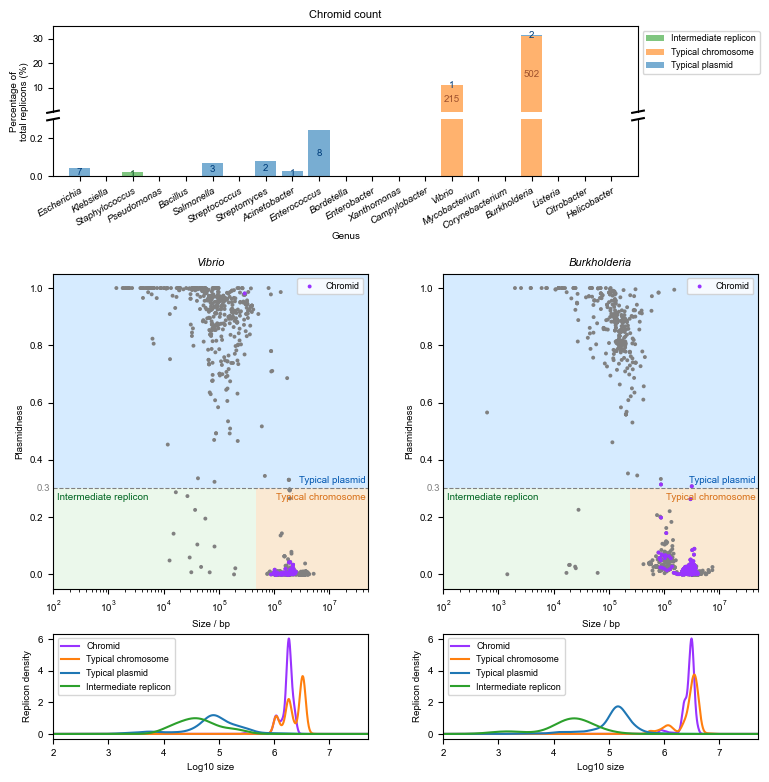

In [4]:
fig = plt.figure(figsize=(7.5, 7.5))
ax_rep = fig.add_axes([0.06, 0.8, 1-0.22, 0.2])
def create_broken_axes(ax, split_ratio=0.7, hspace=0.05):
    fig = ax.figure
    bbox = ax.get_position()

    total_height = bbox.height
    usable_height = total_height - hspace
    top_h = usable_height * split_ratio
    bottom_h = usable_height * (1 - split_ratio)

    ax1 = fig.add_axes([bbox.x0, bbox.y0 + bottom_h + hspace, bbox.width, top_h])
    ax2 = fig.add_axes([bbox.x0, bbox.y0, bbox.width, bottom_h])

    return ax1, ax2

split_ratio=0.6
ax1, ax2 = create_broken_axes(ax_rep, split_ratio=split_ratio, hspace=0.01)
d=0.01
min_ratio = min(split_ratio, 1 - split_ratio)
dy1 = 2 * d / split_ratio * min_ratio
dy2 = 2 * d / (1 - split_ratio) * min_ratio
kwargs = dict(color='black', linewidth=1.5, clip_on=False)
ax1.plot((1-d, 1+d), (0-dy1, 0+dy1), transform=ax1.transAxes, **kwargs)
ax1.plot((-d, d),   (0-dy1, 0+dy1), transform=ax1.transAxes, **kwargs)
ax2.plot((1-d, 1+d), (1-dy2, 1+dy2), transform=ax2.transAxes, **kwargs)
ax2.plot((-d, d),   (1-dy2, 1+dy2), transform=ax2.transAxes, **kwargs)
ax2.spines['top'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.set_xticks([])

cut_site = 0.3
genus_names = pct_plot_df.index.tolist()
bottom = np.zeros(len(genus_names))
colors = [plt.cm.tab10.colors[2], plt.cm.tab10.colors[1], plt.cm.tab10.colors[0], ]
text_colors = ['#004d1a', '#a0522d', '#003d7a']
for idx, cat in enumerate(all_categories):
    pct_vals = pct_plot_df[cat].values
    raw_vals = raw_plot_df[cat].values
    bars = ax1.bar(genus_names, pct_vals, bottom=bottom, label=cat.capitalize(), color=colors[idx], alpha=0.6)
    ax2.bar(genus_names, pct_vals, bottom=bottom, label=cat.capitalize(), color=colors[idx], alpha=0.6)
    
    for i, bar in enumerate(bars):
        height = bar.get_height()
        if int(raw_vals[i]) > 0 and bottom[i] + height / 2 > cut_site:
            ax1.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[i] + height / 2,
                f"{int(raw_vals[i])}",
                ha="center", va="center",
                color=text_colors[idx]
            )
        elif int(raw_vals[i]) > 0 and bottom[i] + height / 2 <= cut_site:
            ax2.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[i] + height / 2,
                f"{int(raw_vals[i])}",
                ha="center", va="center",
                color=text_colors[idx]
            )
    bottom += pct_vals

ax1.set_ylim(cut_site, 35)
ax1.set_xlim(-1, len(pct_plot_df))
ax1.legend(bbox_to_anchor=(1, 1), loc="upper left")
ax2.set_ylim(0, cut_site)
ax2.set_xlim(-1, len(pct_plot_df))
ax2.tick_params(axis='x', labelrotation=30)
plt.setp(ax2.get_xticklabels(), ha='right', rotation_mode='anchor', fontproperties=legend_font)

ax_rep.set_xlabel("Genus", labelpad=40)
ax_rep.set_ylabel("Percentage of\ntotal replicons (%)", labelpad=17)
ax_rep.set_title("Chromid count")
ax_rep.set_xticks([])
ax_rep.set_yticks([])
for spine in ax_rep.spines.values():
    spine.set_visible(False)

ax_s1 = fig.add_axes([0.06, 0.25, 0.42, 0.42])
ax_d1 = fig.add_axes([0.06, 0.05, 0.42, 0.14])
draw_replicon_density(ax_s1, ax_d1, 'Vibrio')

ax_s2 = fig.add_axes([0.08 + 0.5, 0.25, 0.42, 0.42])
ax_d2 = fig.add_axes([0.08 + 0.5, 0.05, 0.42, 0.14])
draw_replicon_density(ax_s2, ax_d2, 'Burkholderia')

rect = plt.Rectangle((0, 0), 1, 1, transform=fig.transFigure, facecolor='none', edgecolor='black', linewidth=2)
#fig.patches.append(rect)

base_folder = f'/active-data/analysis_results/chr_pla/genus'
figure_fold = f'{base_folder}/figures'
os.chdir(figure_fold)
plt.savefig(f"S_all_genera_chromid_result.svg", bbox_inches="tight", transparent=True)
plt.savefig(f"S_all_genera_chromid_result.png", dpi=1000, bbox_inches="tight", transparent=True)
plt.show()